In [2]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# =====================================================================
# 1. UPGRADED CUSTOM PIPELINE TRANSFORMERS
# =====================================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Cleans structural schemas, encodes predictable categories,
    and constructs advanced behavioral matrices with custom engagement elements.
    """
    def __init__(self):
        self.encoded_columns_ = None

    def fit(self, X, y=None):
        X_sample = self.transform(X)
        self.encoded_columns_ = X_sample.columns
        return self

    def transform(self, X):
        X = X.copy()
        
        # Drop unique identifiers safely
        X = X.drop(columns=["CustomerId", "Surname", "Year"], errors="ignore")

        # Basic transformations & logs
        X["balance_log"] = np.log1p(X["Balance"])
        X["salary_log"] = np.log1p(X["EstimatedSalary"])
        X["product_norm"] = X["NumOfProducts"] / 4.0
        X["tenure_norm"] = X["Tenure"] / 10.0
        X["card_flag"] = X["HasCrCard"].astype(int)
        X["active_flag"] = X["IsActiveMember"].astype(int)

        # Interaction terms
        X["salary_balance_ratio"] = X["EstimatedSalary"] / (X["Balance"] + 1)
        X["product_per_tenure"] = X["NumOfProducts"] / (X["Tenure"] + 1)
        
        # Balance Tier Categorization
        X["zero_balance_flag"] = (X["Balance"] == 0).astype(int)
        q75 = X["Balance"].quantile(0.75) if not X["Balance"].empty else 0
        X["high_balance_flag"] = (X["Balance"] >= q75).astype(int)
        
        def balance_bucket(b):
            if b == 0: return "Zero Balance"
            elif b < q75: return "Medium Balance"
            else: return "High Balance"
        X["Balance_Category"] = X["Balance"].apply(balance_bucket)

        # Composite Engagement Scoring Engine (Depth + Frequency + Value)
        X["engagement_score"] = (
            0.40 * X["active_flag"] +
            0.30 * X["product_norm"] +
            0.15 * (X["balance_log"] / (X["balance_log"].max() + 1e-5)) + 
            0.05 * X["card_flag"] +
            0.10 * X["tenure_norm"]
        )

        # Advanced requested behavior features
        X["low_engagement_flag"] = (X["engagement_score"] < 0.3).astype(int)
        X["activity_product_interaction"] = X["active_flag"] * X["NumOfProducts"]
        X["balance_activity_gap"] = X["Balance"] * (1 - X["active_flag"])
        X["tenure_engagement_ratio"] = X["engagement_score"] / (X["Tenure"] + 1)
        X["is_dormant_high_value"] = ((X["active_flag"] == 0) & (X["high_balance_flag"] == 1)).astype(int)
        X["product_intensity"] = pd.cut(X["NumOfProducts"], bins=[0, 1, 2, 4], labels=["Low", "Medium", "High"]).astype(str)

        # One-Hot Encoding for specific categorical strings
        X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

        if self.encoded_columns_ is not None:
            X = X.reindex(columns=self.encoded_columns_, fill_value=0)
            
        return X


class ClusterSegmenter(BaseEstimator, TransformerMixin):
    """
    Automates behavioral cluster discovery. Expanded to 5 clusters to cleanly
    separate Active Casuals from Active Power Core users based on engagement distributions.
    """
    def __init__(self, n_clusters=5, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.cluster_features = [
            "balance_log", 
            "salary_log", 
            "product_norm", 
            "tenure_norm", 
            "engagement_score"
        ]
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=15)
        self.cluster_mapping_ = {}

    def fit(self, X, y=None):
        X_subset = X[self.cluster_features]
        X_scaled = self.scaler.fit_transform(X_subset)
        self.kmeans.fit(X_scaled)
        
        centers = self.kmeans.cluster_centers_
        eng_idx = self.cluster_features.index("engagement_score")
        bal_idx = self.cluster_features.index("balance_log")
        
        # Sort cluster indices by lowest to highest engagement score center
        sorted_by_eng = np.argsort(centers[:, eng_idx])
        
        # Resolve 5-Cluster Topology cleanly across the bimodal distribution
        self.cluster_mapping_[sorted_by_eng[0]] = "Inactive_Disengaged"
        self.cluster_mapping_[sorted_by_eng[4]] = "Active_Power_Core"
        self.cluster_mapping_[sorted_by_eng[3]] = "Active_Casual"
        
        remaining_mid = [sorted_by_eng[1], sorted_by_eng[2]]
        if centers[remaining_mid[0], bal_idx] > centers[remaining_mid[1], bal_idx]:
            self.cluster_mapping_[remaining_mid[0]] = "Inactive_High_Balance"
            self.cluster_mapping_[remaining_mid[1]] = "Inactive_Low_Balance"
        else:
            self.cluster_mapping_[remaining_mid[0]] = "Inactive_Low_Balance"
            self.cluster_mapping_[remaining_mid[1]] = "Inactive_High_Balance"
            
        return self

    def transform(self, X):
        X = X.copy()
        X_subset = X[self.cluster_features]
        X_scaled = self.scaler.transform(X_subset)
        
        # Distance Mapping features
        X["cluster_id"] = self.kmeans.predict(X_scaled)
        cluster_distances = self.kmeans.transform(X_scaled)
        for i in range(self.n_clusters):
            X[f"dist_to_cluster_{i}"] = cluster_distances[:, i]
            
        # Segment Mapping Configuration
        X["Engagement_Segment"] = X["cluster_id"].map(self.cluster_mapping_)
        
        # Binary Tracking Masks
        X["is_active_power_core"] = (X["Engagement_Segment"] == "Active_Power_Core").astype(int)
        X["is_active_casual"] = (X["Engagement_Segment"] == "Active_Casual").astype(int)
        X["is_inactive_disengaged"] = (X["Engagement_Segment"] == "Inactive_Disengaged").astype(int)
        X["is_inactive_high_balance"] = (X["Engagement_Segment"] == "Inactive_High_Balance").astype(int)
        X["is_inactive_low_balance"] = (X["Engagement_Segment"] == "Inactive_Low_Balance").astype(int)

        # Strategic Behavioral Value Segments
        def value_tier(row):
            if row["is_active_power_core"] == 1 or (row["is_active_casual"] == 1 and row.get("high_balance_flag", 0) == 1):
                return "Platinum Value"
            elif row["is_inactive_high_balance"] == 1 or row["is_active_casual"] == 1:
                return "High Value"
            elif row["is_inactive_low_balance"] == 1:
                return "Medium Value"
            else:
                return "Low Value"
                
        X["customer_value_segment"] = X.apply(value_tier, axis=1)
        return X

# =====================================================================
# 2. END-TO-END EXECUTION WORKFLOW & DATASET EXPORTS
# =====================================================================

if __name__ == "__main__":
    # 1. Load Original File
    print("Reading datafinance_v1.1.csv...")
    df = pd.read_csv("datafinance_v1.1.csv")
    
    X = df.drop(columns=["Exited"])
    y = df["Exited"]

    # Stratified Train/Test Partitioning
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Instantiate Transformers for Pipeline and Independent Saving Steps
    fe_transformer = FeatureEngineer()
    cl_transformer = ClusterSegmenter(n_clusters=5, random_state=42)

    print("\nProcessing Step 1 & 2: Transforming Datasets...")
    # Generate the complete processed matrices
    X_train_final = cl_transformer.fit_transform(fe_transformer.fit_transform(X_train))
    X_test_final = cl_transformer.transform(fe_transformer.transform(X_test))

    # Append Target Arrays directly to outputs for complete storage tracking
    X_train_final["Exited"] = y_train.values
    X_test_final["Exited"] = y_test.values

    # Export Processed Partition Files
    X_train_final.to_csv("final_train_engineered_v2.csv", index=False)
    X_test_final.to_csv("final_test_engineered_v2.csv", index=False)
    print("✔ Saved Complete Train Set: 'final_train_engineered_v2.csv'")
    print("✔ Saved Complete Test Set: 'final_test_engineered_v2.csv'")

    # 2. Build and Evaluate Model over Flattened Matrix Data
    categorical_cols = ["Balance_Category", "product_intensity", "Engagement_Segment", "customer_value_segment"]
    categorical_mask = [True if col in categorical_cols else False for col in X_train_final.drop(columns=["Exited"]).columns]
    
    model = HistGradientBoostingClassifier(
        max_iter=250,
        max_depth=6,
        learning_rate=0.04,
        categorical_features=categorical_mask,
        random_state=42,
        class_weight={0: 1.0, 1: 2.2}
    )

    print("\nTraining upgraded bimodal-aware machine learning model...")
    model.fit(X_train_final.drop(columns=["Exited"]), y_train)

    # Performance Audit Execution
    preds = model.predict(X_test_final.drop(columns=["Exited"]))
    probs = model.predict_proba(X_test_final.drop(columns=["Exited"]))[:, 1]

    print("\n" + "="*50)
    print("PRODUCTION MODEL EVALUATION REPORT")
    print("="*50)
    print(classification_report(y_test, preds))
    print(f"Production Area Under ROC Curve (ROC-AUC): {roc_auc_score(y_test, probs):.4f}\n")

    # 3. Generate Consolidated Full Dataset with Appended Metadata for Dashboards/BI
    print("Generating complete master analytics dataset...")
    df_analytics = cl_transformer.transform(fe_transformer.transform(X))
    
    # Inject original keys back into analytics matrix for clear reporting
    if "CustomerId" in df.columns: df_analytics.insert(0, "CustomerId", df["CustomerId"])
    if "Surname" in df.columns: df_analytics.insert(1, "Surname", df["Surname"])
    df_analytics["Exited"] = y.values
    
    df_analytics.to_csv("final_analytics_master_dataset.csv", index=False)
    print("✔ Saved Master Analytics File: 'final_analytics_master_dataset.csv'")
    print("\nProcess finished. Output datasets are ready for downstream model deployment or visualization tools.")

Reading datafinance_v1.1.csv...

Processing Step 1 & 2: Transforming Datasets...
✔ Saved Complete Train Set: 'final_train_engineered_v2.csv'
✔ Saved Complete Test Set: 'final_test_engineered_v2.csv'

Training upgraded bimodal-aware machine learning model...

PRODUCTION MODEL EVALUATION REPORT
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1593
           1       0.63      0.63      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000

Production Area Under ROC Curve (ROC-AUC): 0.8551

Generating complete master analytics dataset...
✔ Saved Master Analytics File: 'final_analytics_master_dataset.csv'

Process finished. Output datasets are ready for downstream model deployment or visualization tools.



Training upgraded bimodal-aware pipeline...

UPGRADED 5-CLUSTER PIPELINE EVALUATION
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1593
           1       0.63      0.63      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000

Optimized ROC-AUC Score: 0.8551



C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_31008\4146490927.py:238: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="viridis")


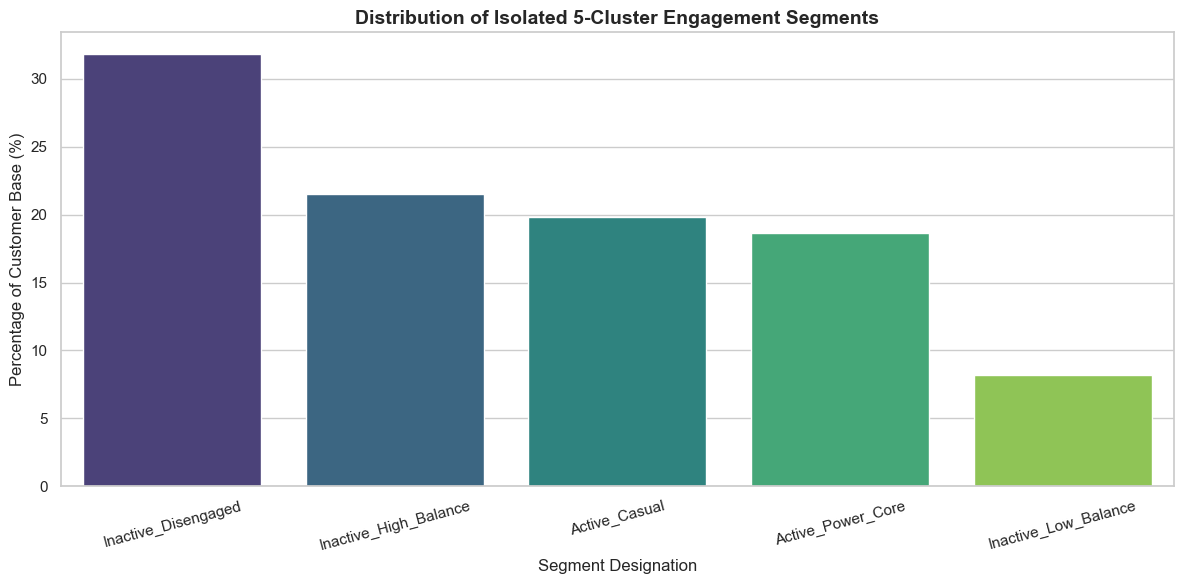

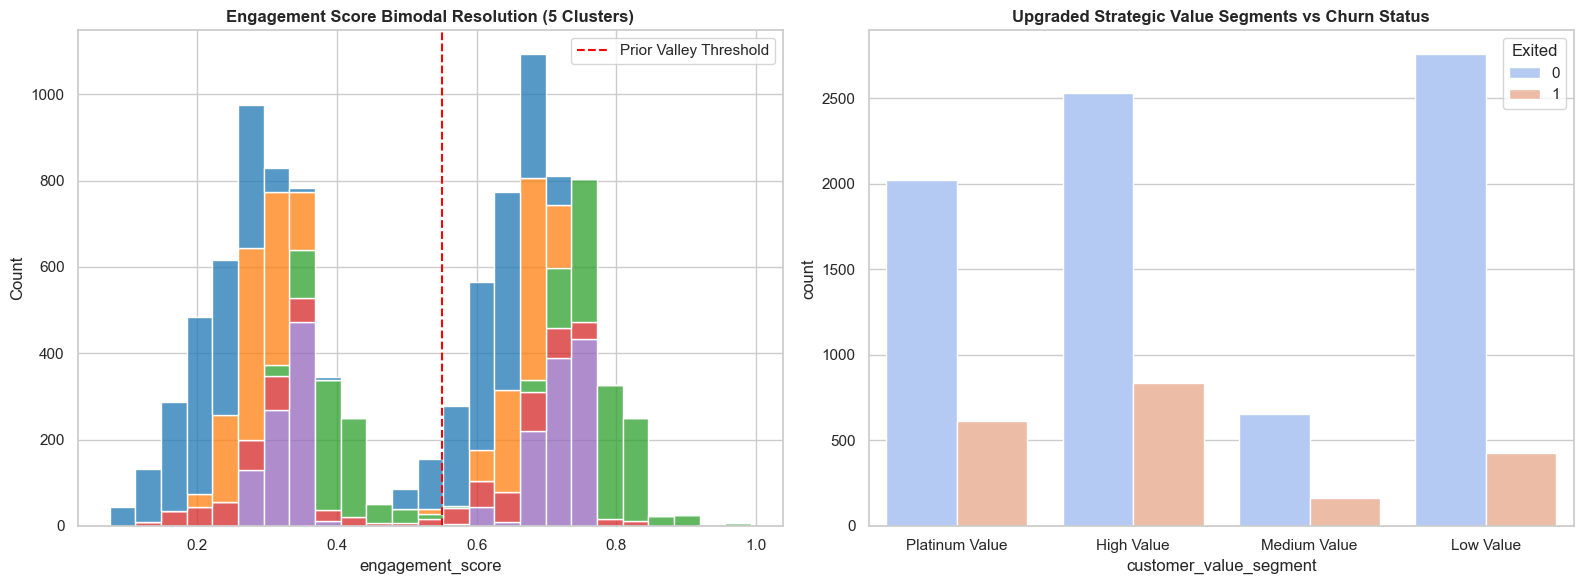

In [3]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. CUSTOM PIPELINE TRANSFORMERS
# =====================================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Cleans structural schemas, encodes predictable categories,
    and constructs advanced behavioral matrices with custom engagement elements.
    """
    def __init__(self):
        self.encoded_columns_ = None

    def fit(self, X, y=None):
        X_sample = self.transform(X)
        self.encoded_columns_ = X_sample.columns
        return self

    def transform(self, X):
        X = X.copy()
        
        # Drop unique identifiers safely
        X = X.drop(columns=["CustomerId", "Surname", "Year"], errors="ignore")

        # Basic transformations & logs
        X["balance_log"] = np.log1p(X["Balance"])
        X["salary_log"] = np.log1p(X["EstimatedSalary"])
        X["product_norm"] = X["NumOfProducts"] / 4.0
        X["tenure_norm"] = X["Tenure"] / 10.0
        X["card_flag"] = X["HasCrCard"].astype(int)
        X["active_flag"] = X["IsActiveMember"].astype(int)

        # Interaction terms
        X["salary_balance_ratio"] = X["EstimatedSalary"] / (X["Balance"] + 1)
        X["product_per_tenure"] = X["NumOfProducts"] / (X["Tenure"] + 1)
        
        # Balance Tier Categorization
        X["zero_balance_flag"] = (X["Balance"] == 0).astype(int)
        q75 = X["Balance"].quantile(0.75) if not X["Balance"].empty else 0
        X["high_balance_flag"] = (X["Balance"] >= q75).astype(int)
        
        def balance_bucket(b):
            if b == 0: return "Zero Balance"
            elif b < q75: return "Medium Balance"
            else: return "High Balance"
        X["Balance_Category"] = X["Balance"].apply(balance_bucket)

        # Advanced Engagement Scoring Engine (Depth + Frequency + Value)
        # Re-scaled to isolate the active bimodal groups cleanly
        X["engagement_score"] = (
            0.40 * X["active_flag"] +
            0.30 * X["product_norm"] +
            0.15 * (X["balance_log"] / (X["balance_log"].max() + 1e-5)) + 
            0.05 * X["card_flag"] +
            0.10 * X["tenure_norm"]
        )

        # Advanced requested behavior features
        X["low_engagement_flag"] = (X["engagement_score"] < 0.3).astype(int)
        X["activity_product_interaction"] = X["active_flag"] * X["NumOfProducts"]
        
        X["balance_activity_gap"] = X["Balance"] * (1 - X["active_flag"])
        X["tenure_engagement_ratio"] = X["engagement_score"] / (X["Tenure"] + 1)
        X["is_dormant_high_value"] = ((X["active_flag"] == 0) & (X["high_balance_flag"] == 1)).astype(int)
        X["product_intensity"] = pd.cut(X["NumOfProducts"], bins=[0, 1, 2, 4], labels=["Low", "Medium", "High"]).astype(str)

        # One-Hot Encoding for specific categorical strings
        X = pd.get_dummies(X, columns=["Geography", "Gender"], drop_first=True)

        if self.encoded_columns_ is not None:
            X = X.reindex(columns=self.encoded_columns_, fill_value=0)
            
        return X


class ClusterSegmenter(BaseEstimator, TransformerMixin):
    """
    Automates behavioral cluster discovery. Expanded to 5 clusters to cleanly
    separate Active Casuals from Active Power Core users based on engagement distributions.
    """
    def __init__(self, n_clusters=5, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.cluster_features = [
            "balance_log", 
            "salary_log", 
            "product_norm", 
            "tenure_norm", 
            "engagement_score"
        ]
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=15)
        self.cluster_mapping_ = {}

    def fit(self, X, y=None):
        X_subset = X[self.cluster_features]
        X_scaled = self.scaler.fit_transform(X_subset)
        self.kmeans.fit(X_scaled)
        
        centers = self.kmeans.cluster_centers_
        eng_idx = self.cluster_features.index("engagement_score")
        bal_idx = self.cluster_features.index("balance_log")
        
        # Sort cluster indices by lowest to highest engagement score center
        sorted_by_eng = np.argsort(centers[:, eng_idx])
        
        # 1. Absolute lowest engagement cluster
        self.cluster_mapping_[sorted_by_eng[0]] = "Inactive_Disengaged"
        
        # 2. Absolute highest engagement cluster -> Active Power Core Users
        self.cluster_mapping_[sorted_by_eng[4]] = "Active_Power_Core"
        
        # 3. Next highest engagement cluster -> Active Casual Users
        self.cluster_mapping_[sorted_by_eng[3]] = "Active_Casual"
        
        # 4. Resolve mid-tier inactive clusters using balance logic
        remaining_mid = [sorted_by_eng[1], sorted_by_eng[2]]
        if centers[remaining_mid[0], bal_idx] > centers[remaining_mid[1], bal_idx]:
            self.cluster_mapping_[remaining_mid[0]] = "Inactive_High_Balance"
            self.cluster_mapping_[remaining_mid[1]] = "Inactive_Low_Balance"
        else:
            self.cluster_mapping_[remaining_mid[0]] = "Inactive_Low_Balance"
            self.cluster_mapping_[remaining_mid[1]] = "Inactive_High_Balance"
            
        return self

    def transform(self, X):
        X = X.copy()
        X_subset = X[self.cluster_features]
        X_scaled = self.scaler.transform(X_subset)
        
        # Standard Distance Maps
        X["cluster_id"] = self.kmeans.predict(X_scaled)
        cluster_distances = self.kmeans.transform(X_scaled)
        for i in range(self.n_clusters):
            X[f"dist_to_cluster_{i}"] = cluster_distances[:, i]
            
        # Segment Mapping Configuration
        X["Engagement_Segment"] = X["cluster_id"].map(self.cluster_mapping_)
        
        # Build binary indicator tracking masks
        X["is_active_power_core"] = (X["Engagement_Segment"] == "Active_Power_Core").astype(int)
        X["is_active_casual"] = (X["Engagement_Segment"] == "Active_Casual").astype(int)
        X["is_inactive_disengaged"] = (X["Engagement_Segment"] == "Inactive_Disengaged").astype(int)
        X["is_inactive_high_balance"] = (X["Engagement_Segment"] == "Inactive_High_Balance").astype(int)
        X["is_inactive_low_balance"] = (X["Engagement_Segment"] == "Inactive_Low_Balance").astype(int)

        # Strategic Behavioral Value Segments
        def value_tier(row):
            if row["is_active_power_core"] == 1 or (row["is_active_casual"] == 1 and row.get("high_balance_flag", 0) == 1):
                return "Platinum Value"
            elif row["is_inactive_high_balance"] == 1 or row["is_active_casual"] == 1:
                return "High Value"
            elif row["is_inactive_low_balance"] == 1:
                return "Medium Value"
            else:
                return "Low Value"
                
        X["customer_value_segment"] = X.apply(value_tier, axis=1)
        return X


# =====================================================================
# 2. RUNNING EXECUTION WORKFLOW WITH LOCAL CSV
# =====================================================================

if __name__ == "__main__":
    # Load original dataset setup
    df = pd.read_csv("datafinance_v1.1.csv")
    
    X = df.drop(columns=["Exited"])
    y = df["Exited"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Temporary validation transformations to parse structural dimensions accurately
    fe_transformer = FeatureEngineer()
    cl_transformer = ClusterSegmenter(n_clusters=5, random_state=42)
    
    X_train_transformed = cl_transformer.fit_transform(fe_transformer.fit_transform(X_train))
    
    # Precise Categorical String Registration for Gradient Booster Matrix Mapping
    categorical_cols = ["Balance_Category", "product_intensity", "Engagement_Segment", "customer_value_segment"]
    categorical_mask = [True if col in categorical_cols else False for col in X_train_transformed.columns]
    
    # 3. BUILD PIPELINE WITH NEW 5-CLUSTER TOPOLOGY
    model_pipeline = Pipeline(steps=[
        ("feature_engineering", FeatureEngineer()),
        ("clustering", ClusterSegmenter(n_clusters=5, random_state=42)),
        ("model", HistGradientBoostingClassifier(
            max_iter=250,
            max_depth=6,
            learning_rate=0.04,
            categorical_features=categorical_mask,
            random_state=42,
            class_weight={0: 1.0, 1: 2.2}
        ))
    ])

    print("\nTraining upgraded bimodal-aware pipeline...")
    model_pipeline.fit(X_train, y_train)

    # 4. EVALUATE PIPELINE PERFORMANCE
    preds = model_pipeline.predict(X_test)
    probs = model_pipeline.predict_proba(X_test)[:, 1]

    print("\n" + "="*50)
    print("UPGRADED 5-CLUSTER PIPELINE EVALUATION")
    print("="*50)
    print(classification_report(y_test, preds))
    print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

    # Transform full original dataframe for reporting visualizations
    df_plot = cl_transformer.transform(fe_transformer.transform(X))
    df_plot["Exited"] = y.values

    # =====================================================================
    # 3. UPGRADED PLOT GENERATION
    # =====================================================================
    sns.set_theme(style="whitegrid")

    # Plot A: Distribution of Engineered Engagement Segments (Barplot)
    plt.figure(figsize=(12, 6))
    segment_counts = df_plot["Engagement_Segment"].value_counts(normalize=True) * 100
    sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="viridis")
    plt.title("Distribution of Isolated 5-Cluster Engagement Segments", fontsize=14, fontweight="bold")
    plt.xlabel("Segment Designation", fontsize=12)
    plt.ylabel("Percentage of Customer Base (%)", fontsize=12)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Plot C: Segregated Balance Categories & Engagement Score Histograms
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.histplot(
        data=df_plot, x="engagement_score", hue="Engagement_Segment", 
        multiple="stack", palette="tab10", ax=axes[0]
    )
    axes[0].set_title("Engagement Score Bimodal Resolution (5 Clusters)", fontsize=12, fontweight="bold")
    axes[0].axvline(0.55, color='red', linestyle='--', label='Prior Valley Threshold')
    axes[0].legend()
    
    sns.countplot(
        data=df_plot, x="customer_value_segment", hue="Exited", 
        palette="coolwarm", order=["Platinum Value", "High Value", "Medium Value", "Low Value"], ax=axes[1]
    )
    axes[1].set_title("Upgraded Strategic Value Segments vs Churn Status", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

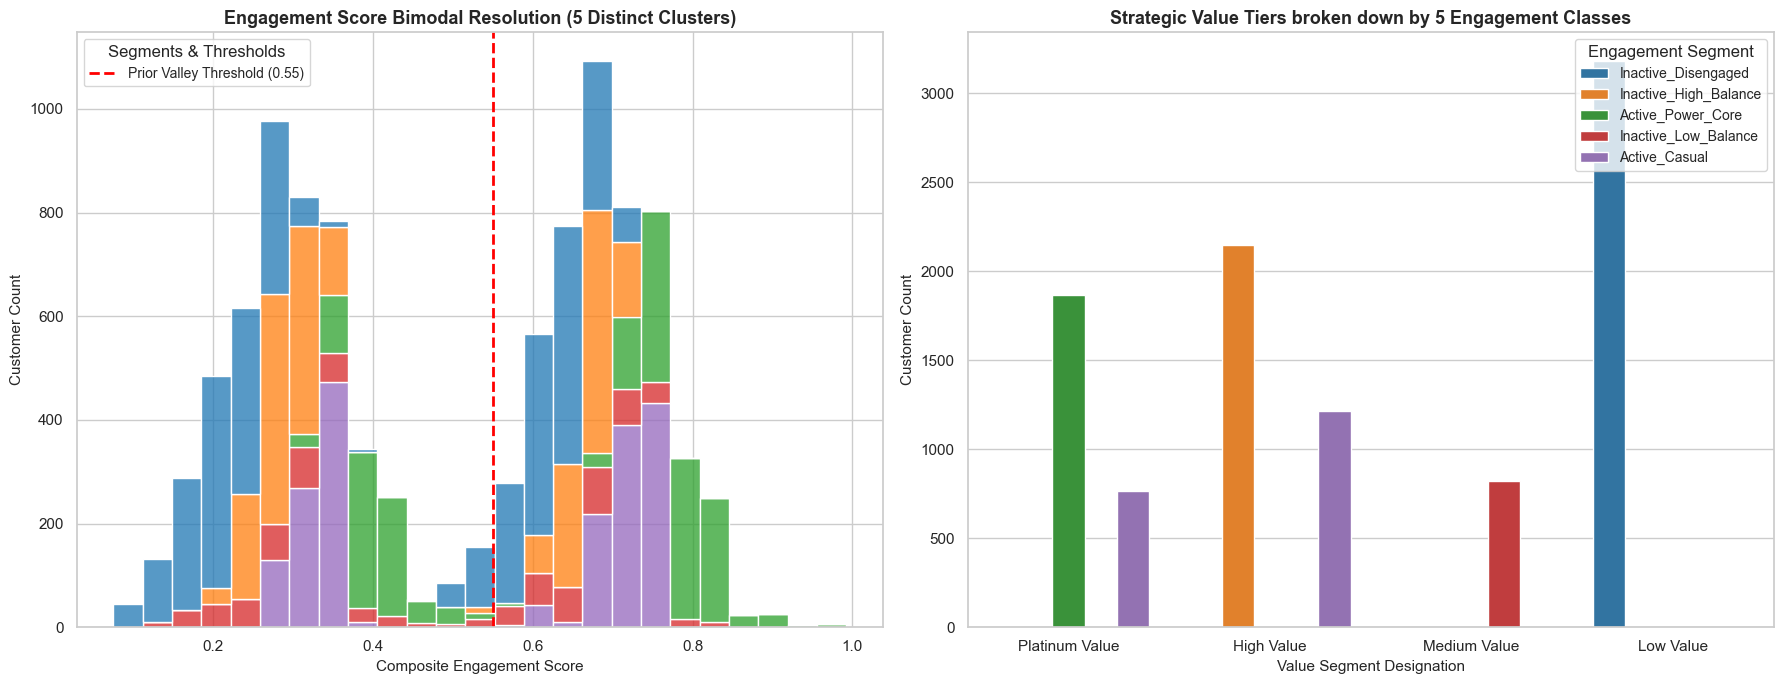

In [4]:
# =====================================================================
# UPGRADED PLOT C: RESOLVED BIMODAL HISTOGRAM & SEGMENT COUNTPLOT
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- SUBPLOT 1: Engagement Score Histogram (5 Clusters) ---
# This will cleanly display all 5 color classes across the bimodal distribution
hist = sns.histplot(
    data=df_plot, 
    x="engagement_score", 
    hue="Engagement_Segment", 
    multiple="stack", 
    palette="tab10", 
    ax=axes[0]
)
# Add the prior valley threshold line
axes[0].axvline(0.55, color='red', linestyle='--', linewidth=2, label='Prior Valley Threshold (0.55)')

# Re-build the legend for axes[0] to include BOTH the 5 cluster colors AND the threshold line
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title="Segments & Thresholds", loc="upper left", fontsize=10)
axes[0].set_title("Engagement Score Bimodal Resolution (5 Distinct Clusters)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Composite Engagement Score", fontsize=11)
axes[0].set_ylabel("Customer Count", fontsize=11)


# --- SUBPLOT 2: Strategic Value Segments Cross-Referenced by the 5 Classes ---
# Changing hue to Engagement_Segment ensures you see exactly which clusters build up each Value Tier
sns.countplot(
    data=df_plot, 
    x="customer_value_segment", 
    hue="Engagement_Segment", 
    palette="tab10", 
    order=["Platinum Value", "High Value", "Medium Value", "Low Value"], 
    ax=axes[1]
)
axes[1].set_title("Strategic Value Tiers broken down by 5 Engagement Classes", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Value Segment Designation", fontsize=11)
axes[1].set_ylabel("Customer Count", fontsize=11)
# Move legend outside slightly if it crowds the bars
axes[1].legend(title="Engagement Segment", loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()